# Générateur de contenu personnalisé basé sur l'IA

Ce projet simule un système de recommandation capable de générer des suggestions personnalisées (livres) en se basant sur les profils et préférences des utilisateurs. Nous allons suivre les étapes suivantes :

1. Définir les profils et les préférences des utilisateurs.
2. Générer et analyser des données (utilisateurs, activités, intérêts).
3. Créer un moteur de recommandation.
4. Visualiser les informations.


## 1. Définir les profils et les préférences des utilisateurs

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # Reproductibilité

num_users = 1000
interests_categories = [
    'Fiction', 'Science-Fiction', 'Fantasy', 'Romance', 'Thriller',
    'Biographie', 'Histoire', 'Science', 'Technologie', 'Cuisine',
    'Voyage', 'Développement Personnel', 'Poésie', 'Art', 'Jeunesse'
]
users     = [f"U{i:04d}" for i in range(1, num_users + 1)]
user_interests = np.random.choice(interests_categories, num_users)

# 1. Génération des données de base
ages    = np.random.randint(18, 65, num_users).astype(float)
genders = np.random.choice(['Male', 'Female'], num_users).astype(object)
locs    = np.random.choice(
    ['Paris', 'Moscou', 'Marseille', 'Buenos Aires', 'Pékin', 'Séoul', 'Abidjan', 'Dakar'],
    num_users
).astype(object)

# 2. Injection de valeurs manquantes (10 %)
missing_rate = 0.10

for arr, missing_idx in [
    (ages,    np.random.choice(num_users, int(num_users * missing_rate), replace=False)),
    (genders, np.random.choice(num_users, int(num_users * missing_rate), replace=False)),
    (locs,    np.random.choice(num_users, int(num_users * missing_rate), replace=False)),
]:
    if arr.dtype == float:
        arr[missing_idx] = np.nan
    else:
        arr[missing_idx] = None

# 3. Injection de données aberrantes (5 %)
outlier_rate = 0.05

# Âges impossibles
outlier_age_idx = np.random.choice(
    np.where(~np.isnan(ages))[0],
    int(num_users * outlier_rate), replace=False
)
ages[outlier_age_idx] = np.random.choice([-5, 0, 130, 999], len(outlier_age_idx))

# Genres invalides
outlier_gender_idx = np.random.choice(
    [i for i in range(num_users) if genders[i] is not None],
    int(num_users * outlier_rate), replace=False
)
genders[outlier_gender_idx] = np.random.choice(['UNKNOWN', '???', '123'], len(outlier_gender_idx))

# Localisations invalides
outlier_loc_idx = np.random.choice(
    [i for i in range(num_users) if locs[i] is not None],
    int(num_users * outlier_rate), replace=False
)
locs[outlier_loc_idx] = np.random.choice(['N/A', '', 'ZZZ', 'Paris  '], len(outlier_loc_idx))

# 4. Construction du DataFrame de base
user_profiles_df = pd.DataFrame({
    'UserID':    users,
    'Age':       ages,
    'Gender':    genders,
    'Location':  locs,
    'Interests': user_interests
})

# 5. Injection de doublons (5 %)
#    On duplique des lignes existantes en leur donnant un nouveau
#    UserID mais en gardant les mêmes Age / Gender / Location /
#    Interests, ce qui simule des inscriptions en double réelles.
duplicate_rate = 0.05
num_duplicates = int(num_users * duplicate_rate)

# Sélectionner des lignes source à dupliquer
source_idx = np.random.choice(num_users, num_duplicates, replace=False)
duplicate_rows = user_profiles_df.iloc[source_idx].copy()

# Deux variantes de doublons :
#   a) UserID différent  – même contenu (doublon "invisible")
#   b) UserID identique  – doublon strict (même ligne complète)
half = num_duplicates // 2

# Variante a : nouveau UserID (U9001, U9002, …)
new_ids = [f"U{9000 + i + 1:04d}" for i in range(half)]
duplicate_rows.loc[duplicate_rows.index[:half], 'UserID'] = new_ids

# Variante b : UserID identique (vraie ligne dupliquée)
# On laisse le UserID original → doublon strict sur toutes les colonnes
# Concaténer et mélanger
user_profiles_df = pd.concat(
    [user_profiles_df, duplicate_rows], ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

total_rows = len(user_profiles_df)


In [30]:
user_profiles_df.head()

,UserID,Age,Gender,Location,Interests
0,U0353,29.0,Female,Marseille,Romance
1,U0690,23.0,Female,Séoul,Cuisine
2,U0486,49.0,Male,NaN,Cuisine
3,U0389,21.0,Male,Dakar,Poésie
4,U0032,55.0,Female,Buenos Aires,Développement Personnel


## 2. Générer et analyser des données

### 2.1 Génération de journaux d'activité synthétiques

In [31]:
# 1. GÉNÉRATION DES DONNÉES

activity_types = ['view', 'like', 'share', 'purchase', 'skip']

# Exemple de catégories
book_categories = [
    'Science', 'Technology', 'History',
    'Literature', 'Business', 'Health'
]

num_activities = 1000
missing_rate = 0.18
outlier_rate = 0.10
duplicate_rate = 0.08

np.random.seed(42)

activity_data = []

for _ in range(num_activities):

    user_id = np.random.randint(1, 201)

    activity_type = np.random.choice(
        activity_types,
        p=[0.40, 0.25, 0.15, 0.10, 0.10]
    )

    book_category = np.random.choice(book_categories)

    timestamp = (
        pd.Timestamp("2023-01-01")
        + pd.to_timedelta(
            np.random.randint(0, 365*24*60),
            unit="m"
        )
    )

    activity_data.append({
        "UserID": user_id,
        "Timestamp": timestamp,
        "ActivityType": activity_type,
        "BookCategory": book_category
    })

activity_logs_df = pd.DataFrame(activity_data)

# 2. INJECTION DES VALEURS MANQUANTES

for col in ["UserID", "ActivityType", "BookCategory"]:

    idx = np.random.choice(
        activity_logs_df.index,
        int(len(activity_logs_df)*missing_rate),
        replace=False
    )

    activity_logs_df.loc[idx, col] = np.nan

# Timestamp manquant
idx_ts = np.random.choice(
    activity_logs_df.index,
    int(len(activity_logs_df)*missing_rate),
    replace=False
)

activity_logs_df.loc[idx_ts, "Timestamp"] = pd.NaT

# 3. INJECTION DES ANOMALIES

n_outliers = int(len(activity_logs_df)*outlier_rate)

# ActivityType invalide
idx = activity_logs_df["ActivityType"].dropna().sample(
    n_outliers
).index

activity_logs_df.loc[idx, "ActivityType"] = np.random.choice(
    ["UNKNOWN", "BOT", "###", ""],
    size=n_outliers
)

# BookCategory invalide
idx = activity_logs_df["BookCategory"].dropna().sample(
    n_outliers
).index

activity_logs_df.loc[idx, "BookCategory"] = np.random.choice(
    ["NULL", "ERROR", "???", ""],
    size=n_outliers
)

# Dates aberrantes
idx = activity_logs_df["Timestamp"].dropna().sample(
    n_outliers
).index

activity_logs_df.loc[idx, "Timestamp"] = np.random.choice(
    pd.to_datetime([
        "1900-01-01",
        "1970-01-01",
        "2099-12-31"
    ]),
    size=n_outliers
)

# 4. AJOUT DES DOUBLONS

n_dup = int(len(activity_logs_df)*duplicate_rate)

duplicates = activity_logs_df.sample(
    n_dup,
    replace=True
)

activity_logs_df = pd.concat(
    [activity_logs_df, duplicates],
    ignore_index=True
)

activity_logs_df = activity_logs_df.sample(
    frac=1
).reset_index(drop=True)



### 2.2 Prétraitement et nettoyage des données

  RAPPORT DE QUALITÉ DES DONNÉES - VUE COMPLÈTE

 DataFrame généré : 1050 lignes × 5 colonnes
  (incluant données de base + valeurs manquantes + aberrantes + doublons)


 APERÇU DES PREMIÈRES LIGNES :


,UserID,Age,Gender,Location,Interests
0,U0353,29.0,Female,Marseille,Romance
1,U0690,23.0,Female,Séoul,Cuisine
2,U0486,49.0,Male,NaN,Cuisine
3,U0389,21.0,Male,Dakar,Poésie
4,U0032,55.0,Female,Buenos Aires,Développement Personnel
5,U0443,60.0,Female,Marseille,Développement Personnel
6,U0199,23.0,Female,Abidjan,Romance
7,U0426,55.0,Female,Buenos Aires,Voyage
8,U0108,60.0,Male,Paris,Science
9,U0715,26.0,Male,NaN,Cuisine



 DONNÉES MANQUANTES (NaN/None) :
UserID         0
Age          104
Gender       105
Location     108
Interests      0
dtype: int64

  Total cellules manquantes : 317 / 5250

 DOUBLONS :
  → Doublons stricts (ligne entière)    : 25
  → Doublons de contenu (sans UserID)   : 82
  → UserID dupliqués                    : 25

  Exemple de doublons stricts :


,UserID,Age,Gender,Location,Interests
983,U0002,NaN,Female,Marseille,Romance
852,U0027,38.0,Male,Dakar,Biographie
1023,U0100,62.0,Female,NaN,Développement Personnel
132,U0185,21.0,Female,Marseille,Voyage
1026,U0190,41.0,NaN,Pékin,Cuisine
547,U0250,26.0,Male,Abidjan,Technologie
480,U0322,47.0,Female,Marseille,Voyage
941,U0410,53.0,Male,Pékin,Fiction
996,U0498,25.0,Female,Marseille,Histoire
870,U0525,35.0,Female,Marseille,Biographie


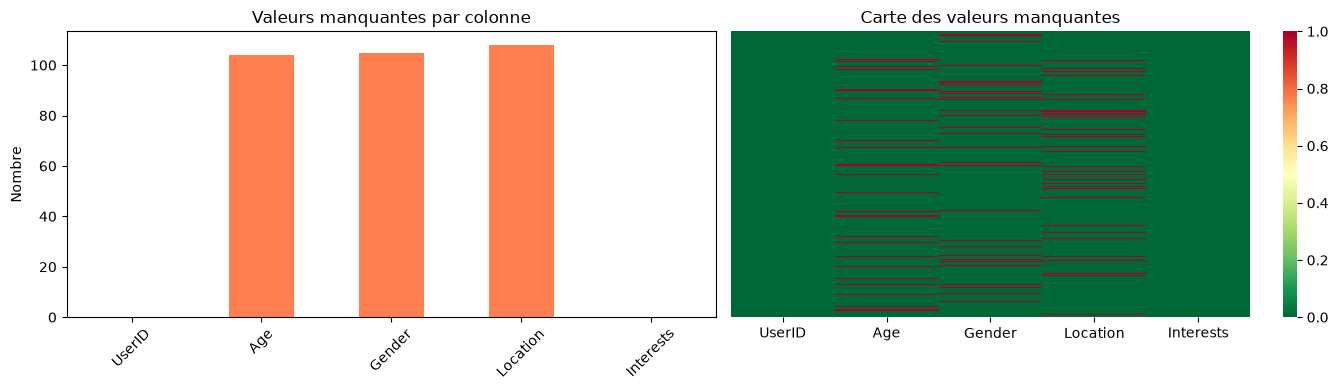


 VALEURS ABERRANTES DÉTECTÉES :

  Âges aberrants (< 18 ou > 65 ou NaN) :
   → 158 problèmes (15.05%)
   → Valeurs uniques : [np.float64(-5.0), np.float64(0.0), np.float64(130.0), np.float64(999.0)]


,UserID,Age,Gender,Location,Interests
12,U0159,130.0,Female,Dakar,Science-Fiction
19,U0651,-5.0,Male,NaN,Romance
21,U0848,NaN,Male,Pékin,Cuisine
25,U0060,NaN,Female,Moscou,Technologie
27,U0071,NaN,Female,Dakar,Thriller
30,U0142,0.0,Female,Marseille,Fantasy
31,U0391,NaN,Female,NaN,Art
37,U0307,999.0,NaN,Moscou,Romance



  Genres aberrants :
   → 156 problèmes (14.86%)
   → Valeurs uniques : ['123', '???', 'UNKNOWN']


,UserID,Age,Gender,Location,Interests
11,U0676,34.0,NaN,Pékin,Voyage
13,U0476,19.0,NaN,Marseille,Science
15,U9025,20.0,NaN,Abidjan,Science
16,U0618,45.0,123,Moscou,Fiction
32,U0492,50.0,NaN,Marseille,Technologie
35,U0750,50.0,NaN,Moscou,Développement Personnel
37,U0307,999.0,NaN,Moscou,Romance
42,U0678,64.0,NaN,Moscou,Poésie



  Localisations aberrantes :
   → 161 problèmes (15.33%)
   → Valeurs uniques : ['', 'N/A', 'Paris  ', 'ZZZ']


,UserID,Age,Gender,Location,Interests
2,U0486,49.0,Male,NaN,Cuisine
9,U0715,26.0,Male,NaN,Cuisine
19,U0651,-5.0,Male,NaN,Romance
23,U0829,37.0,Female,NaN,Développement Personnel
31,U0391,NaN,Female,NaN,Art
57,U0200,19.0,NaN,NaN,Art
81,U0880,62.0,Male,ZZZ,Voyage
83,U0219,21.0,Male,NaN,Technologie


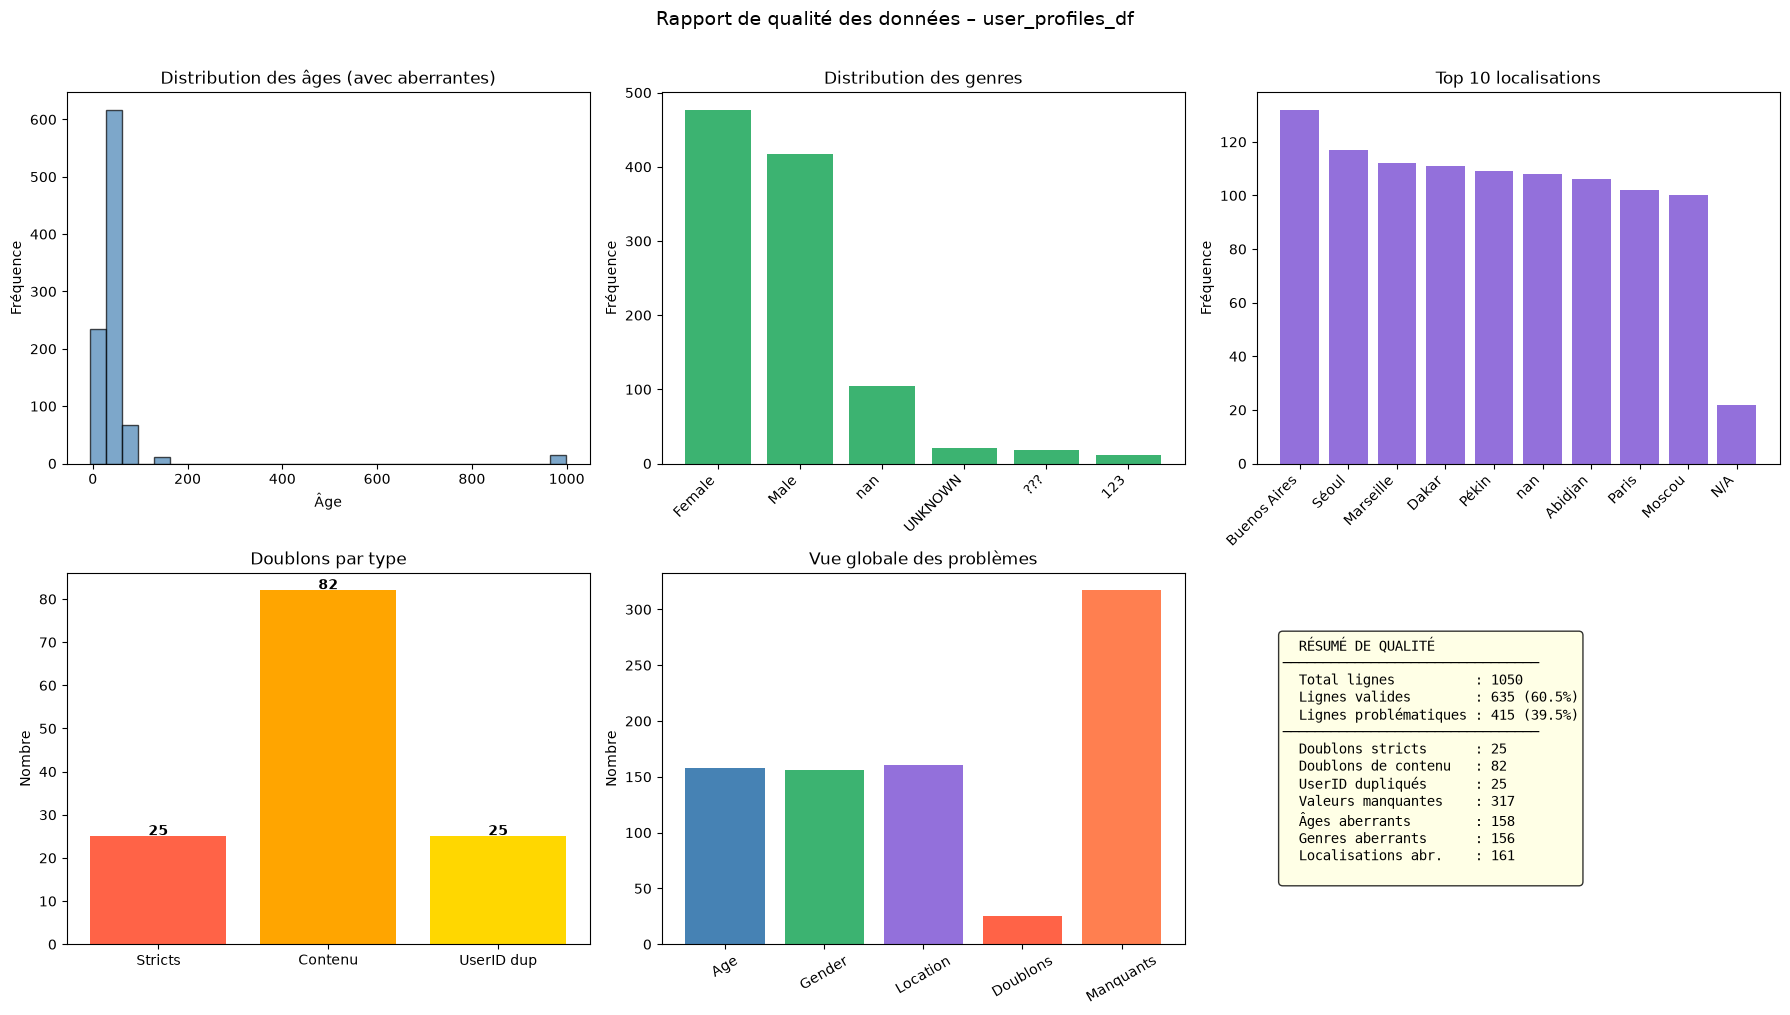


 Rapport de qualité de données terminé


In [32]:
# 6. Rapport de qualité
print("=" * 80)
print("  RAPPORT DE QUALITÉ DES DONNÉES - VUE COMPLÈTE")
print("=" * 80)

print(f"\n DataFrame généré : {total_rows} lignes × {user_profiles_df.shape[1]} colonnes")
print("  (incluant données de base + valeurs manquantes + aberrantes + doublons)\n")

print("\n APERÇU DES PREMIÈRES LIGNES :")
display(user_profiles_df.head(15))

# Valeurs manquantes
print("\n DONNÉES MANQUANTES (NaN/None) :")
missing_counts = user_profiles_df.isnull().sum()
print(missing_counts)
print(f"\n  Total cellules manquantes : {missing_counts.sum()} / {user_profiles_df.size}")

# Doublons
print("\n DOUBLONS :")

# 5a – Lignes entièrement dupliquées (toutes colonnes identiques)
strict_dupes = user_profiles_df.duplicated(keep='first')
print(f"  → Doublons stricts (ligne entière)    : {strict_dupes.sum()}")

# 5b – Doublons sur le contenu métier (sans UserID)
content_cols = ['Age', 'Gender', 'Location', 'Interests']
content_dupes = user_profiles_df.duplicated(subset=content_cols, keep='first')
print(f"  → Doublons de contenu (sans UserID)   : {content_dupes.sum()}")

# 5c – UserID en double (même identifiant attribué deux fois)
userid_dupes = user_profiles_df.duplicated(subset='UserID', keep='first')
print(f"  → UserID dupliqués                    : {userid_dupes.sum()}")

print("\n  Exemple de doublons stricts :")
display(
    user_profiles_df[strict_dupes]
    .sort_values('UserID')
    .head(10)
)

# Visualisation : valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

missing_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Valeurs manquantes par colonne')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    user_profiles_df.isnull(), cbar=True, ax=axes[1],
    cmap='RdYlGn_r', yticklabels=False
)
axes[1].set_title('Carte des valeurs manquantes')
plt.tight_layout()
plt.show()

# Valeurs aberrantes
valid_genders   = ['Male', 'Female']
valid_locations = ['Paris', 'Moscou', 'Marseille', 'Buenos Aires',
                   'Pékin', 'Séoul', 'Abidjan', 'Dakar']

print("\n VALEURS ABERRANTES DÉTECTÉES :")

print("\n  Âges aberrants (< 18 ou > 65 ou NaN) :")
age_outliers = user_profiles_df[
    user_profiles_df['Age'].isna() |
    (user_profiles_df['Age'] < 18) |
    (user_profiles_df['Age'] > 65)
]
print(f"   → {len(age_outliers)} problèmes ({len(age_outliers)/total_rows*100:.2f}%)")
print(f"   → Valeurs uniques : {sorted(age_outliers['Age'].dropna().unique())}")
display(age_outliers.head(8))

print("\n  Genres aberrants :")
gender_outliers = user_profiles_df[
    user_profiles_df['Gender'].isna() |
    (~user_profiles_df['Gender'].isin(valid_genders))
]
print(f"   → {len(gender_outliers)} problèmes ({len(gender_outliers)/total_rows*100:.2f}%)")
print(f"   → Valeurs uniques : {sorted(gender_outliers['Gender'].dropna().unique())}")
display(gender_outliers.head(8))

print("\n  Localisations aberrantes :")
location_outliers = user_profiles_df[
    user_profiles_df['Location'].isna() |
    (~user_profiles_df['Location'].isin(valid_locations))
]
print(f"   → {len(location_outliers)} problèmes ({len(location_outliers)/total_rows*100:.2f}%)")
print(f"   → Valeurs uniques : {sorted(location_outliers['Location'].dropna().unique())}")
display(location_outliers.head(8))

# Visualisations principales
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Histogramme des âges
axes[0, 0].hist(user_profiles_df['Age'].dropna(), bins=30,
                color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution des âges (avec aberrantes)')
axes[0, 0].set_xlabel('Âge')
axes[0, 0].set_ylabel('Fréquence')

# Distribution des genres
gc = user_profiles_df['Gender'].value_counts(dropna=False)
axes[0, 1].bar(range(len(gc)), gc.values, color='mediumseagreen')
axes[0, 1].set_xticks(range(len(gc)))
axes[0, 1].set_xticklabels(gc.index, rotation=45, ha='right')
axes[0, 1].set_title('Distribution des genres')
axes[0, 1].set_ylabel('Fréquence')

# Distribution des localisations
lc = user_profiles_df['Location'].value_counts(dropna=False).head(10)
axes[0, 2].bar(range(len(lc)), lc.values, color='mediumpurple')
axes[0, 2].set_xticks(range(len(lc)))
axes[0, 2].set_xticklabels(lc.index, rotation=45, ha='right')
axes[0, 2].set_title('Top 10 localisations')
axes[0, 2].set_ylabel('Fréquence')

# Résumé de qualité – doublons
dupe_data = {
    'Stricts':    strict_dupes.sum(),
    'Contenu':    content_dupes.sum(),
    'UserID dup': userid_dupes.sum(),
}
axes[1, 0].bar(dupe_data.keys(), dupe_data.values(), color=['tomato', 'orange', 'gold'])
axes[1, 0].set_title('Doublons par type')
axes[1, 0].set_ylabel('Nombre')
for i, (k, v) in enumerate(dupe_data.items()):
    axes[1, 0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Résumé de qualité – problèmes par colonne
problem_counts = {
    'Age':      len(age_outliers),
    'Gender':   len(gender_outliers),
    'Location': len(location_outliers),
    'Doublons': strict_dupes.sum(),
    'Manquants': missing_counts.sum(),
}
axes[1, 1].bar(problem_counts.keys(), problem_counts.values(),
               color=['steelblue', 'mediumseagreen', 'mediumpurple', 'tomato', 'coral'])
axes[1, 1].set_title('Vue globale des problèmes')
axes[1, 1].set_ylabel('Nombre')
axes[1, 1].tick_params(axis='x', rotation=30)

# Tableau récapitulatif texte
problematic_rows = user_profiles_df[
    user_profiles_df['Age'].isna() | (user_profiles_df['Age'] < 18) | (user_profiles_df['Age'] > 65) |
    user_profiles_df['Gender'].isna() | (~user_profiles_df['Gender'].isin(valid_genders)) |
    user_profiles_df['Location'].isna() | (~user_profiles_df['Location'].isin(valid_locations)) |
    strict_dupes
]
valid_rows = total_rows - len(problematic_rows)

quality_text = (
    "  RÉSUMÉ DE QUALITÉ\n"
    + "─" * 32 + "\n"
    f"  Total lignes          : {total_rows}\n"
    f"  Lignes valides        : {valid_rows} ({valid_rows/total_rows*100:.1f}%)\n"
    f"  Lignes problématiques : {len(problematic_rows)} ({len(problematic_rows)/total_rows*100:.1f}%)\n"
    + "─" * 32 + "\n"
    f"  Doublons stricts      : {strict_dupes.sum()}\n"
    f"  Doublons de contenu   : {content_dupes.sum()}\n"
    f"  UserID dupliqués      : {userid_dupes.sum()}\n"
    f"  Valeurs manquantes    : {missing_counts.sum()}\n"
    f"  Âges aberrants        : {len(age_outliers)}\n"
    f"  Genres aberrants      : {len(gender_outliers)}\n"
    f"  Localisations abr.    : {len(location_outliers)}\n"
)
axes[1, 2].axis('off')
axes[1, 2].text(
    0.05, 0.5, quality_text, fontsize=10,
    verticalalignment='center', family='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.suptitle("Rapport de qualité des données – user_profiles_df", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print(" Rapport de qualité de données terminé")
print("=" * 80)

### 2.2.1 Nettoyage de `user_profiles_df`

Taille du dataset : 1050

Valeurs manquantes
UserID         0
Age          104
Gender       105
Location     108
Interests      0
dtype: int64

Doublons
25


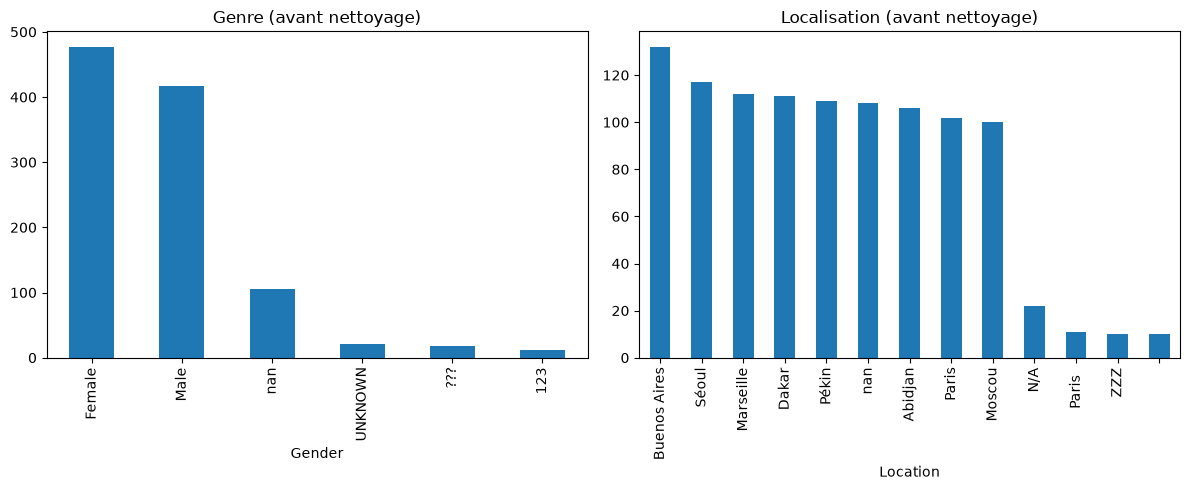


APRÈS NETTOYAGE
Nombre de lignes : 914

Valeurs manquantes
UserID       0
Age          0
Gender       0
Location     0
Interests    0
dtype: int64

Doublons
0


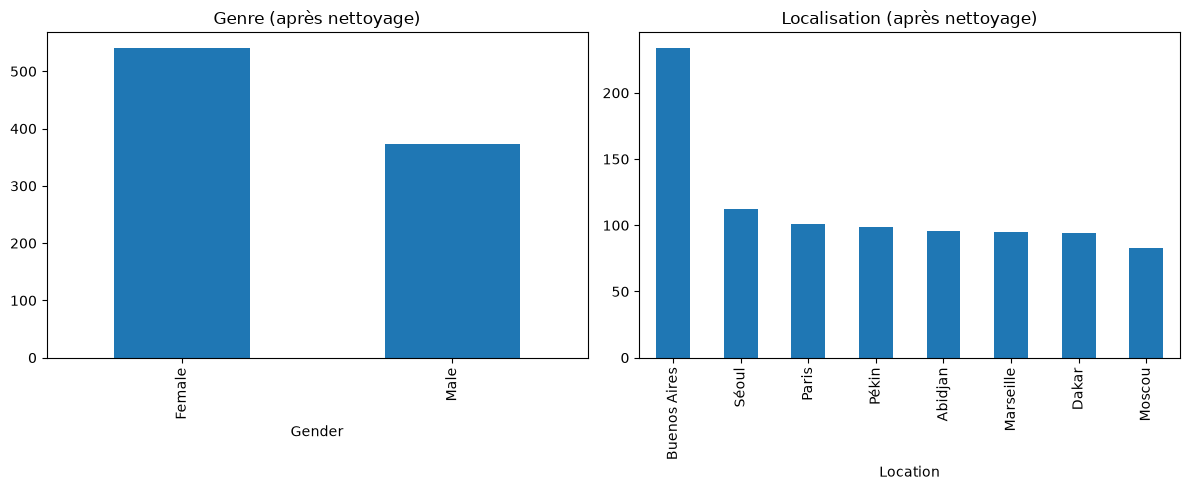


Nombre d'intérêts uniques : 15


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 1. RAPPORT INITIAL
# ===============================

print("Taille du dataset :", len(user_profiles_df))

print("\nValeurs manquantes")
print(user_profiles_df.isnull().sum())

print("\nDoublons")
print(user_profiles_df.duplicated().sum())

# ===============================
# 2. VISUALISATION AVANT NETTOYAGE
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

user_profiles_df["Gender"].value_counts(
    dropna=False
).plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Genre (avant nettoyage)")

user_profiles_df["Location"].value_counts(
    dropna=False
).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Localisation (avant nettoyage)")

plt.tight_layout()
plt.show()

# ===============================
# 3. NETTOYAGE DES DONNÉES
# ===============================

clean_df = user_profiles_df.copy()

# ----- Age -----

clean_df["Age"] = pd.to_numeric(
    clean_df["Age"],
    errors="coerce"
)

clean_df.loc[
    (clean_df["Age"] < 18) |
    (clean_df["Age"] > 65),
    "Age"
] = np.nan

clean_df["Age"] = clean_df["Age"].fillna(
    clean_df["Age"].median()
)

clean_df["Age"] = clean_df["Age"].astype(int)

# ----- Gender -----

valid_genders = ["Male", "Female"]

clean_df.loc[
    ~clean_df["Gender"].isin(valid_genders),
    "Gender"
] = np.nan

clean_df["Gender"] = clean_df["Gender"].fillna(
    clean_df["Gender"].mode()[0]
)

# ----- Location -----

valid_locations = [
    "Paris",
    "Moscou",
    "Marseille",
    "Buenos Aires",
    "Pékin",
    "Séoul",
    "Abidjan",
    "Dakar"
]

clean_df["Location"] = (
    clean_df["Location"]
    .astype(str)
    .str.strip()
)

clean_df.loc[
    ~clean_df["Location"].isin(valid_locations),
    "Location"
] = np.nan

clean_df["Location"] = clean_df["Location"].fillna(
    clean_df["Location"].mode()[0]
)

# ----- Interests -----

def parse_interests(value):
    if pd.isna(value) or value == "":
        return []

    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        return [
            str(x).strip()
            for x in value
            if str(x).strip()
        ]

    if isinstance(value, str):
        return [
            x.strip()
            for x in value.split(",")
            if x.strip()
        ]

    return []

clean_df["Interests"] = clean_df["Interests"].apply(
    parse_interests
)

# ===============================
# 4. SUPPRESSION DES DOUBLONS
# ===============================

# Doublons UserID
clean_df = clean_df.drop_duplicates(
    subset=["UserID"],
    keep="first"
)

# Conversion temporaire des listes en chaînes
clean_df["Interests_str"] = clean_df["Interests"].apply(
    lambda x: ",".join(sorted(x))
    if isinstance(x, (list, tuple, np.ndarray, pd.Series))
    else ""
)

clean_df = clean_df.drop_duplicates(
    subset=[
        "Age",
        "Gender",
        "Location",
        "Interests_str"
    ],
    keep="first"
)

clean_df.drop(
    columns=["Interests_str"],
    inplace=True
)

# Réindexation
clean_df.reset_index(
    drop=True,
    inplace=True
)

# ===============================
# 5. RAPPORT APRÈS NETTOYAGE
# ===============================

print("\n==============================")
print("APRÈS NETTOYAGE")
print("==============================")

print("Nombre de lignes :", len(clean_df))

print("\nValeurs manquantes")
print(clean_df.isnull().sum())

print("\nDoublons")
print(
    clean_df.assign(
        Interests=clean_df["Interests"].apply(
            lambda x: tuple(x) if isinstance(x, (list, tuple, np.ndarray, pd.Series)) else x
        )
    ).duplicated().sum()
)

# ===============================
# 6. VISUALISATION APRÈS NETTOYAGE
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

clean_df["Gender"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Genre (après nettoyage)")

clean_df["Location"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Localisation (après nettoyage)")

plt.tight_layout()
plt.show()

all_interests = []

for interests in clean_df["Interests"]:
    if isinstance(interests, (list, tuple, np.ndarray, pd.Series)):
        all_interests.extend(
            str(item).strip()
            for item in interests
            if str(item).strip()
        )
    elif isinstance(interests, str) and interests.strip():
        all_interests.append(interests.strip())

interests_categories = sorted(
    list(set(all_interests))
)

interests_categories = sorted(
    list(set(all_interests))
)

print(
    "\nNombre d'intérêts uniques :",
    len(interests_categories)
)

### 2.2.2 Nettoyage de `activity_logs_df`

Taille du dataset : 1080

Valeurs manquantes
UserID          201
Timestamp       197
ActivityType    195
BookCategory    192
dtype: int64

Doublons
86


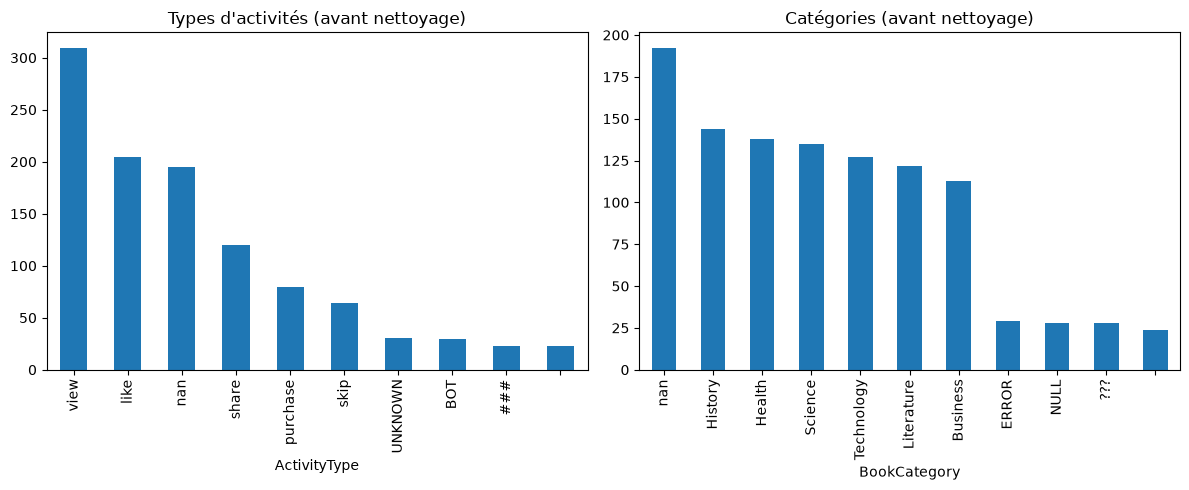


APRÈS NETTOYAGE
Nombre de lignes : 292

Valeurs manquantes
UserID          0
Timestamp       0
ActivityType    0
BookCategory    0
dtype: int64

Doublons
0


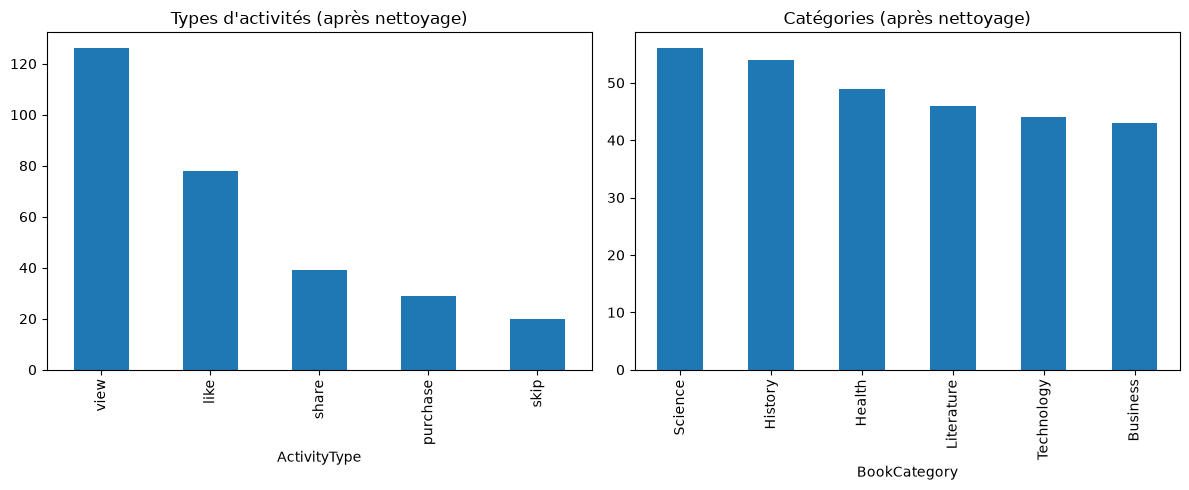

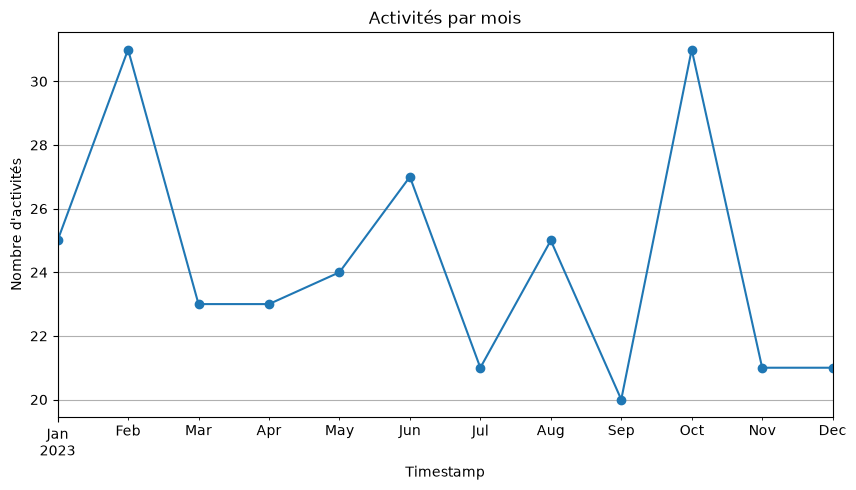

In [43]:
# ===============================
# 5. RAPPORT INITIAL
# ===============================

print("Taille du dataset :", len(activity_logs_df))
print("\nValeurs manquantes")
print(activity_logs_df.isnull().sum())

print("\nDoublons")
print(activity_logs_df.duplicated().sum())

# ===============================
# 6. VISUALISATION AVANT NETTOYAGE
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

activity_logs_df["ActivityType"].value_counts(
    dropna=False
).plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Types d'activités (avant nettoyage)")

activity_logs_df["BookCategory"].value_counts(
    dropna=False
).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Catégories (avant nettoyage)")

plt.tight_layout()
plt.show()

# ===============================
# 7. NETTOYAGE DES DONNÉES
# ===============================

clean_df = activity_logs_df.copy()

# Suppression des doublons
clean_df = clean_df.drop_duplicates()

# Suppression des valeurs manquantes
clean_df = clean_df.dropna()

# Conservation des activités valides
clean_df = clean_df[
    clean_df["ActivityType"].isin(activity_types)
]

# Conservation des catégories valides
clean_df = clean_df[
    clean_df["BookCategory"].isin(book_categories)
]

# Conservation des dates de l'année 2023
clean_df = clean_df[
    (clean_df["Timestamp"] >= "2023-01-01")
    &
    (clean_df["Timestamp"] <= "2023-12-31")
]

# Réindexation
clean_df.reset_index(drop=True, inplace=True)

# ===============================
# 8. RAPPORT APRÈS NETTOYAGE
# ===============================

print("\n==============================")
print("APRÈS NETTOYAGE")
print("==============================")

print("Nombre de lignes :", len(clean_df))

print("\nValeurs manquantes")
print(clean_df.isnull().sum())

print("\nDoublons")
print(clean_df.duplicated().sum())

# ===============================
# 9. VISUALISATION APRÈS NETTOYAGE
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

clean_df["ActivityType"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Types d'activités (après nettoyage)")

clean_df["BookCategory"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Catégories (après nettoyage)")

plt.tight_layout()
plt.show()

# ===============================
# 10. ÉVOLUTION TEMPORELLE
# ===============================

monthly = (
    clean_df
    .set_index("Timestamp")
    .resample("ME")
    .size()
)

plt.figure(figsize=(10,5))
monthly.plot(marker="o")
plt.title("Activités par mois")
plt.ylabel("Nombre d'activités")
plt.grid(True)
plt.show()

### 2.3 Analyse exploratoire des données (EDA)

#### 2.3.1 Distribution des centres d'intérêt des utilisateurs

C:\Users\meles\AppData\Local\Temp\ipykernel_14288\1958322761.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interests_counts.index, y=interests_counts.values, palette='viridis')


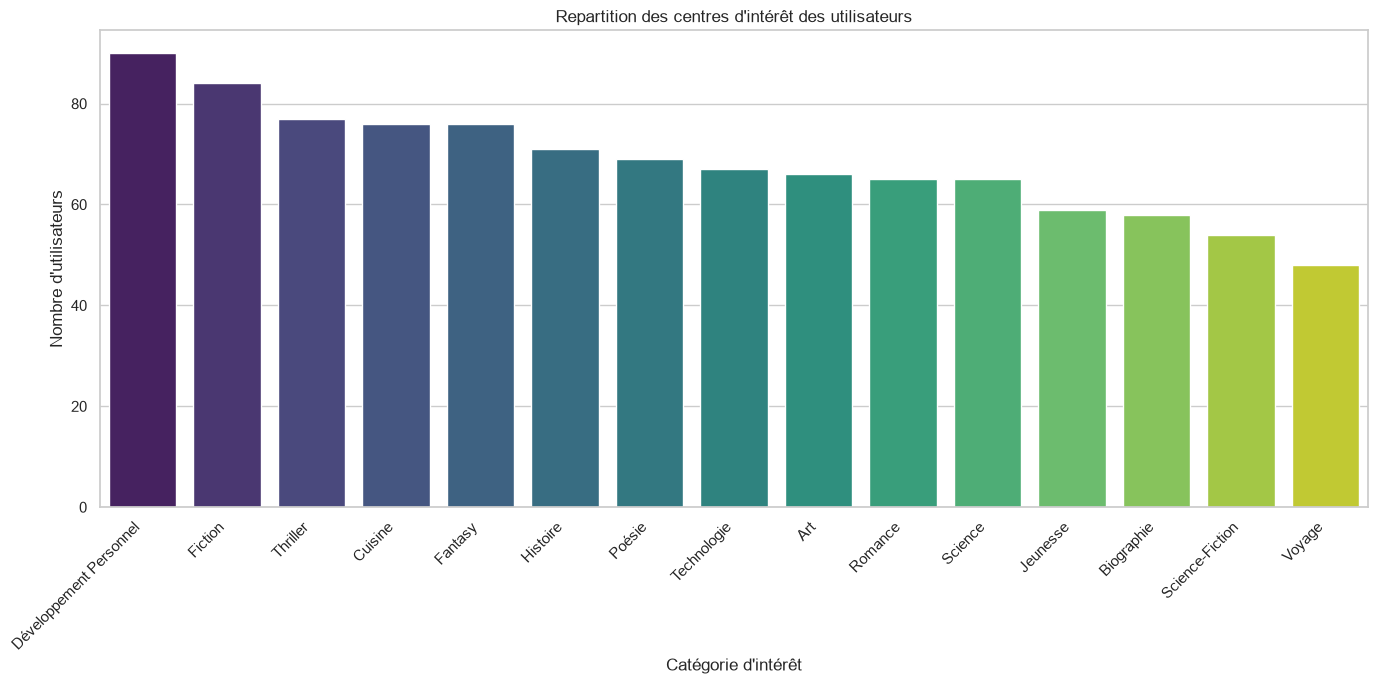

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd # Ensure pandas is imported

plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style='whitegrid')

# user_profiles_df_cleaned is assumed to be defined and cleaned by previous cells.
# Its 'Interests' column should already contain lists of strings.

# Aplatir la liste des intérêts pour compter la fréquence de chaque catégorie
all_interests = []
if 'user_profiles_df_cleaned' not in globals():
    if 'clean_df' in globals():
        user_profiles_df_cleaned = clean_df.copy()
    elif 'user_profiles_df' in globals():
        user_profiles_df_cleaned = user_profiles_df.copy()
    else:
        raise NameError("user_profiles_df_cleaned n'est pas défini et aucun clean_df/user_profiles_df de repli n'est disponible.")

for entry in user_profiles_df_cleaned['Interests']:
    if isinstance(entry, (list, tuple, set)):
        all_interests.extend(entry)
    elif pd.notna(entry):
        all_interests.append(str(entry).strip())

interests_counts = pd.Series(all_interests).value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=interests_counts.index, y=interests_counts.values, palette='viridis')
plt.title("Repartition des centres d'intérêt des utilisateurs")
plt.xlabel("Catégorie d'intérêt")
plt.ylabel("Nombre d'utilisateurs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
interests_counts

Développement Personnel    90
Fiction                    84
Thriller                   77
Cuisine                    76
Fantasy                    76
Histoire                   71
Poésie                     69
Technologie                67
Art                        66
Romance                    65
Science                    65
Jeunesse                   59
Biographie                 58
Science-Fiction            54
Voyage                     48
Name: count, dtype: int64

#### 2.3.2 Intensité d'activité par heure

In [ ]:
# Garantir que activity_logs_df_cleaned existe (utiliser clean_df si disponible, sinon créer un fallback à partir de activity_logs_df)
if 'activity_logs_df_cleaned' not in globals():
    if 'clean_df' in globals():
        activity_logs_df_cleaned = clean_df.copy()
    elif 'activity_logs_df' in globals():
        activity_logs_df_cleaned = activity_logs_df.drop_duplicates().dropna(subset=['UserID','ActivityType','BookCategory','Timestamp']).copy()
        activity_logs_df_cleaned = activity_logs_df_cleaned[
            (activity_logs_df_cleaned['Timestamp'] >= "2023-01-01") &
            (activity_logs_df_cleaned['Timestamp'] <= "2023-12-31")
        ].reset_index(drop=True)
    else:
        raise NameError("Neither 'activity_logs_df_cleaned', 'clean_df' nor 'activity_logs_df' are defined in the notebook.")

# Utiliser les utilitaires partagés pour extraire et tracer l'intensité par heure
try:
    from utils import extract_hour_counts, plot_activity_by_hour
except Exception:
    # Si l'import échoue, tomber sur la logique locale (compatibilité)
    def extract_hour_counts(df, timestamp_col='Timestamp'):
        df = df.dropna(subset=[timestamp_col]).copy()
        df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
        df = df.dropna(subset=[timestamp_col])
        hours = df[timestamp_col].dt.hour
        counts = hours.value_counts().sort_index()
        all_hours = pd.Series(0, index=np.arange(24))
        return all_hours.add(counts, fill_value=0).astype(int)

    def plot_activity_by_hour(counts, figsize=(14, 7), palette='plasma'):
        plt.figure(figsize=figsize)
        sns.barplot(x=counts.index, y=counts.values, palette=palette)
        plt.title("Intensité d'activité par heure")
        plt.xlabel("Heure de la journée")
        plt.ylabel("Nombre d'activités")
        plt.xticks(range(0, 24))
        plt.tight_layout()
        plt.show()

activity_by_hour = extract_hour_counts(activity_logs_df_cleaned, timestamp_col='Timestamp')
plot_activity_by_hour(activity_by_hour)


#### 2.3.3 Analyse de la distribution des centres d'intérêt avec SciPy

In [47]:
from scipy.stats import chisquare
import numpy as np # Ensure numpy is imported

# We have `interests_counts` from `fd322ee9`
observed_frequencies = interests_counts.values

total_interest_occurrences = observed_frequencies.sum()

if len(observed_frequencies) > 0 and total_interest_occurrences > 0: # Only proceed if there are observed interests and total occurrences
    num_unique_observed_categories = len(observed_frequencies)
    expected_frequency_per_category = total_interest_occurrences / num_unique_observed_categories
    expected_frequencies = np.array([expected_frequency_per_category] * num_unique_observed_categories)

    if np.all(expected_frequencies > 0):
        chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

        print(f"Statistique du chi-carré pour les intérêts : {chi2_stat:.2f}")
        print(f"Valeur p : {p_value:.3f}")

        if p_value < 0.05:
            print("La valeur p est inférieure à 0.05, ce qui suggère que la distribution observée des intérêts est significativement différente d'une distribution uniforme.")
            print("Cela indique que certains intérêts sont préférés de manière disproportionnée par rapport à d'autres.")
        else:
            print("La valeur p est supérieure à 0.05, ce qui suggère que nous n'avons pas assez de preuves pour rejeter l'hypothèse d'une distribution uniforme des intérêts.")
    else:
        print("Impossible d'effectuer le test du chi-carré : les fréquences attendues doivent être positives.")
else:
    print("Impossible d'effectuer le test du chi-carré : aucune catégorie d'intérêt observée ou total d'occurrences nul.")

Statistique du chi-carré pour les intérêts : 25.72
Valeur p : 0.028
La valeur p est inférieure à 0.05, ce qui suggère que la distribution observée des intérêts est significativement différente d'une distribution uniforme.
Cela indique que certains intérêts sont préférés de manière disproportionnée par rapport à d'autres.


#### 2.3.4 Cartes thermiques de l'intensité d'activité par heure et par catégorie

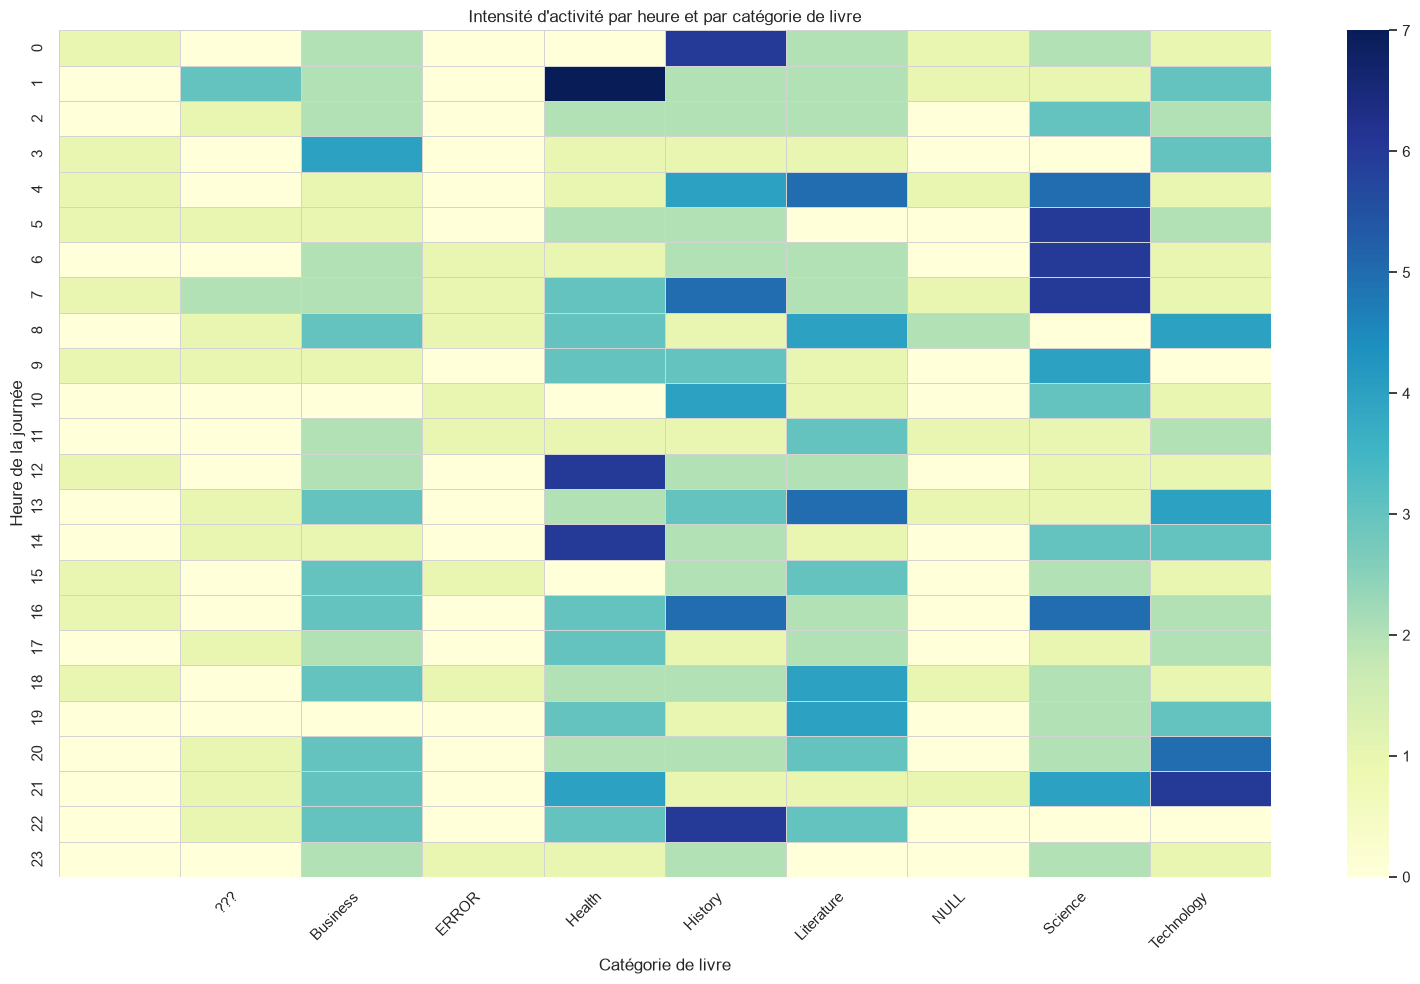

In [49]:
# Créer une colonne 'Hour' si elle n'existe pas déjà (au cas où la cellule précédente n'ait pas été exécutée)
if 'activity_logs_df_cleaned' not in globals():
    if 'activity_logs_df' in globals():
        activity_logs_df_cleaned = activity_logs_df.drop_duplicates().dropna(
            subset=['UserID', 'ActivityType', 'BookCategory', 'Timestamp']
        ).copy()
        activity_logs_df_cleaned['Timestamp'] = pd.to_datetime(
            activity_logs_df_cleaned['Timestamp'], errors='coerce'
        )
        activity_logs_df_cleaned = activity_logs_df_cleaned[
            activity_logs_df_cleaned['Timestamp'].between('2023-01-01', '2023-12-31')
        ].reset_index(drop=True)
    else:
        raise NameError("activity_logs_df_cleaned n'est pas défini et activity_logs_df est introuvable.")

if 'Hour' not in activity_logs_df_cleaned.columns:
    activity_logs_df_cleaned['Hour'] = activity_logs_df_cleaned['Timestamp'].dt.hour

# Pivoter les données pour créer une matrice d'intensité d'activité par heure et par catégorie
activity_heatmap_data = activity_logs_df_cleaned.groupby(['Hour', 'BookCategory']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 10))
sns.heatmap(activity_heatmap_data, cmap='YlGnBu', linewidths=.5, linecolor='lightgray')
plt.title("Intensité d'activité par heure et par catégorie de livre")
plt.xlabel("Catégorie de livre")
plt.ylabel("Heure de la journée")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Créer un moteur de recommandation

Pour créer le moteur de recommandation, nous allons définir une classe `RecommendationEngine` qui pourra :
1. Associer les préférences des utilisateurs aux catégories de contenu.
2. Générer des suggestions personnalisées en fonction des intérêts et des habitudes d'activité.
3. Adapter dynamiquement les suggestions à l'aide d'une logique conditionnelle.
4. Utiliser des métriques de similarité de SciPy pour comparer les profils utilisateurs et recommander des articles basés sur des utilisateurs similaires.

In [50]:
from scipy.spatial.distance import cosine, euclidean

class RecommendationEngine:
    def __init__(self, user_profiles_df, activity_logs_df, interests_categories):
        self.user_profiles = user_profiles_df.set_index('UserID')
        self.activity_logs = activity_logs_df
        self.interests_categories = interests_categories
        self.user_interest_vectors = self._create_user_interest_vectors()

    def _create_user_interest_vectors(self):
        """Crée des vecteurs binaires d'intérêt pour chaque utilisateur."""
        user_interest_vectors = {}
        for user_id, row in self.user_profiles.iterrows():
            vector = [1 if interest in row['Interests'] else 0 for interest in self.interests_categories]
            user_interest_vectors[user_id] = np.array(vector)
        return user_interest_vectors

    def _get_user_preferred_categories(self, user_id):
        """Récupère les catégories préférées d'un utilisateur."""
        if user_id not in self.user_profiles.index:
            return []
        return self.user_profiles.loc[user_id, 'Interests']

    def _get_popular_categories(self, top_n=5):
        """Récupère les catégories de livres les plus populaires d'après les logs d'activité."""
        return self.activity_logs['BookCategory'].value_counts().head(top_n).index.tolist()

    def get_personalized_suggestions(self, user_id, num_suggestions=3):
        """Génère des suggestions personnalisées pour un utilisateur donné.
        La logique de suggestion prend en compte les intérêts de l'utilisateur
        et les catégories populaires.
        """
        if user_id not in self.user_profiles.index:
            print(f"Utilisateur {user_id} non trouvé.")
            return []

        preferred_categories = self._get_user_preferred_categories(user_id)
        popular_categories = self._get_popular_categories(top_n=5)

        suggestions = set()

        # 1. Suggestions basées sur les intérêts directs de l'utilisateur
        for category in preferred_categories:
            suggestions.add(f"Livre de {category}")

        # 2. Suggestions basées sur les activités récentes (par exemple, ce qu'ils ont le plus "aimé" ou "acheté")
        user_recent_activity = self.activity_logs[self.activity_logs['UserID'] == user_id]
        if not user_recent_activity.empty:
            # Prioriser les catégories 'purchase' ou 'like'
            for activity_type in ['purchase', 'like']:
                recent_preferred = user_recent_activity[user_recent_activity['ActivityType'] == activity_type]['BookCategory'].value_counts().index.tolist()
                for category in recent_preferred:
                    suggestions.add(f"Livre similaire à vos récents {activity_type}s en {category}")

        # 3. Suggestions basées sur les catégories populaires si l'utilisateur a peu d'intérêts ou d'activités
        if len(suggestions) < num_suggestions and popular_categories:
            for category in popular_categories:
                suggestions.add(f"Livre populaire de {category}")

        # Logique conditionnelle simple: Si l'utilisateur est âgé, suggérer des biographies ou histoire
        user_age = self.user_profiles.loc[user_id, 'Age']
        if user_age >= 50 and 'Biographie' not in preferred_categories and 'Histoire' not in preferred_categories:
            suggestions.add("Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire")

        # Adapter les suggestions à la taille demandée
        return list(suggestions)[:num_suggestions]

    def find_similar_users(self, target_user_id, metric='cosine', top_n=5):
        """Trouve les utilisateurs les plus similaires à un utilisateur cible
        en utilisant la distance euclidienne ou la similarité cosinus.
        """
        if target_user_id not in self.user_interest_vectors:
            print(f"Utilisateur cible {target_user_id} non trouvé.")
            return []

        target_vector = self.user_interest_vectors[target_user_id]
        similarities = []

        for user_id, user_vector in self.user_interest_vectors.items():
            if user_id == target_user_id: # Ne pas comparer l'utilisateur à lui-même
                continue

            if metric == 'cosine':
                # Cosine similarity est 1 - cosine distance
                similarity = 1 - cosine(target_vector, user_vector)
            elif metric == 'euclidean':
                # Plus la distance euclidienne est petite, plus ils sont similaires
                similarity = -euclidean(target_vector, user_vector) # Inverser pour trier par "similarité" (distance plus petite = similarité plus grande)
            else:
                raise ValueError("Métrique non supportée. Utilisez 'cosine' ou 'euclidean'.")

            similarities.append((user_id, similarity))

        # Trier par similarité (décroissant pour cosine, croissant pour euclidean inversé)
        similarities.sort(key=lambda x: x[1], reverse=True)

        return similarities[:top_n]

    def get_recommendations_from_similar_users(self, target_user_id, num_suggestions=3, metric='cosine'):
        """Génère des recommandations basées sur les intérêts d'utilisateurs similaires."""
        similar_users = self.find_similar_users(target_user_id, metric=metric, top_n=5)
        if not similar_users:
            return self.get_personalized_suggestions(target_user_id, num_suggestions)

        # Collecter les intérêts des utilisateurs similaires
        similar_users_interests = set()
        for user_id, _ in similar_users:
            for interest in self._get_user_preferred_categories(user_id):
                similar_users_interests.add(interest)

        # Exclure les intérêts déjà connus de l'utilisateur cible
        target_user_known_interests = set(self._get_user_preferred_categories(target_user_id))
        recommended_interests = list(similar_users_interests - target_user_known_interests)

        # Si pas d'intérêts nouveaux, revenir aux suggestions personnalisées
        if not recommended_interests:
            return self.get_personalized_suggestions(target_user_id, num_suggestions)

        # Recommander les catégories les plus fréquentes parmi les utilisateurs similaires et non encore connues
        # Ou simplement les premières pour cet exemple
        suggestions = [f"Basé sur des utilisateurs similaires: Livre de {interest}" for interest in recommended_interests[:num_suggestions]]

        # Compléter avec des suggestions personnalisées si pas assez de recommandations similaires
        if len(suggestions) < num_suggestions:
            remaining_suggestions = self.get_personalized_suggestions(target_user_id, num_suggestions - len(suggestions))
            suggestions.extend(remaining_suggestions)

        return suggestions[:num_suggestions]

# Initialiser le moteur de recommandation
re_engine = RecommendationEngine(user_profiles_df_cleaned, activity_logs_df_cleaned, interests_categories)

# Exemple d'utilisation
print("\n--- Exemples de suggestions --- ")

sample_user_id = np.random.choice(user_profiles_df_cleaned['UserID'])
print(f"\nSuggestions personnalisées pour {sample_user_id} (Age: {user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == sample_user_id, 'Age'].iloc[0]}) :")
suggestions = re_engine.get_personalized_suggestions(sample_user_id, num_suggestions=5)
for s in suggestions:
    print(f"- {s}")

print(f"\nSuggestions basées sur des utilisateurs similaires pour {sample_user_id} :")
similar_user_suggestions = re_engine.get_recommendations_from_similar_users(sample_user_id, num_suggestions=5, metric='cosine')
for s in similar_user_suggestions:
    print(f"- {s}")

# Exemple avec un autre utilisateur pour illustrer la logique conditionnelle
# Trouver un utilisateur de plus de 50 ans avec peu d'intérêts en biographie/histoire
older_user_id = user_profiles_df_cleaned[
    (user_profiles_df_cleaned['Age'] >= 50) &
    (~user_profiles_df_cleaned['Interests'].apply(lambda x: 'Biographie' in x or 'Histoire' in x))
]['UserID'].sample(1).iloc[0]

print(f"\nSuggestions personnalisées pour {older_user_id} (Age: {user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == older_user_id, 'Age'].iloc[0]} ans) :")
suggestions_older = re_engine.get_personalized_suggestions(older_user_id, num_suggestions=5)
for s in suggestions_older:
    print(f"- {s}")



--- Exemples de suggestions --- 

Suggestions personnalisées pour U0077 (Age: 49) :
- Livre populaire de Literature
- Livre populaire de Science
- Livre populaire de Health
- Livre populaire de Business
- Livre populaire de History

Suggestions basées sur des utilisateurs similaires pour U0077 :
- Livre populaire de Literature
- Livre populaire de Science
- Livre populaire de Health
- Livre populaire de Business
- Livre populaire de History

Suggestions personnalisées pour U0659 (Age: 60 ans) :
- Livre populaire de Literature
- Livre de Science
- Livre populaire de Science
- Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire
- Livre populaire de Health


## 4. Visualiser les informations

### 4.1 Catégories les plus recommandées par segment d'utilisateurs

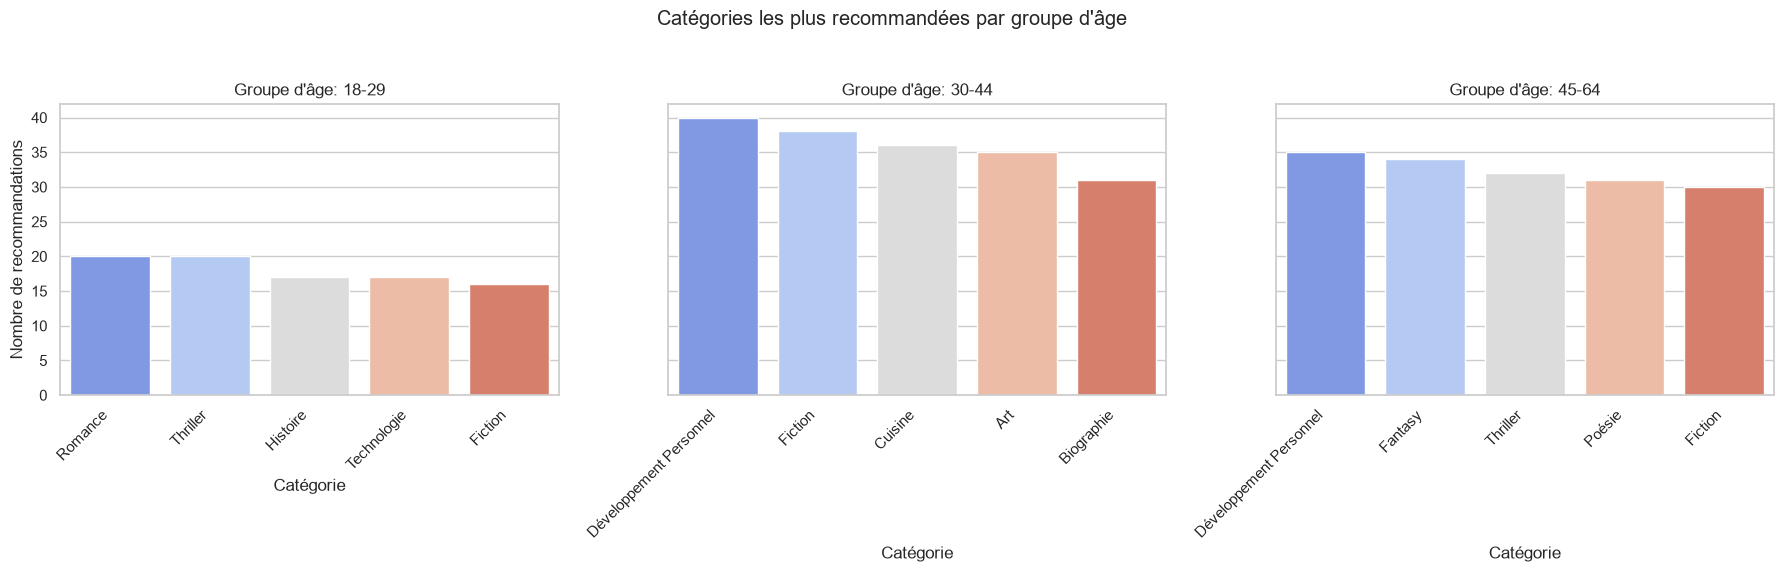

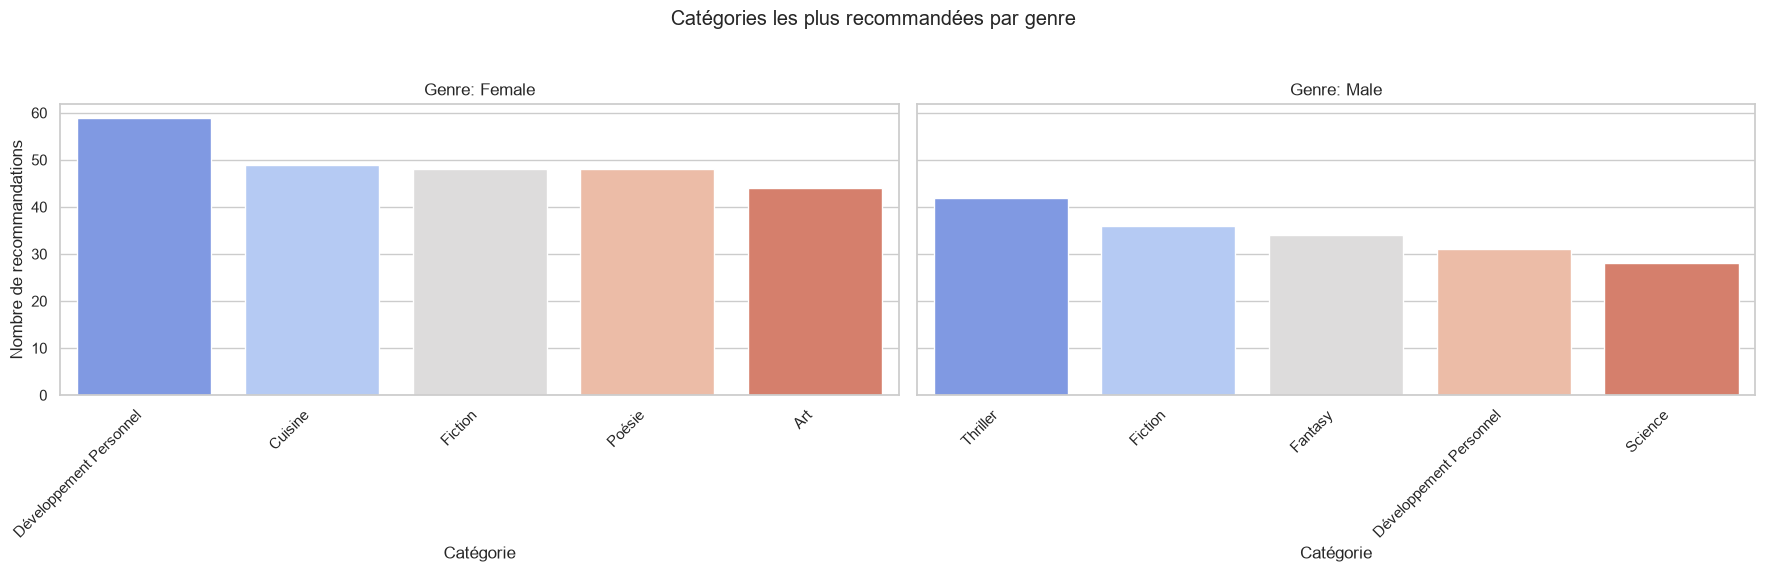

In [52]:
# Pour visualiser les catégories les plus recommandées par segment, nous devons d'abord générer des recommandations pour chaque utilisateur.
# Nous allons nous concentrer sur un segment simple, par exemple 'Gender' ou 'Age Group'.

# Créer des groupes d'âge pour une meilleure segmentation
user_profiles_df_cleaned['AgeGroup'] = pd.cut(
    user_profiles_df_cleaned['Age'],
    bins=[18, 30, 45, 65],
    labels=['18-29', '30-44', '45-64'],
    right=False
)

# Collecter les recommandations pour chaque utilisateur et chaque segment
recommendations_data = []

for user_id in user_profiles_df_cleaned['UserID']:
    user_segment_gender = user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == user_id, 'Gender'].iloc[0]
    user_segment_age_group = user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == user_id, 'AgeGroup'].iloc[0]

    # Obtenir les suggestions personnalisées (nous pouvons choisir une des méthodes, ici la principale)
    suggestions = re_engine.get_personalized_suggestions(user_id, num_suggestions=1) # Prendre la top 1 suggestion pour la simplicité

    if suggestions:
        # Extraire la catégorie du livre de la suggestion (simpliste, à adapter si les formats de suggestions varient)
        # Exemple: 'Livre de Fiction' -> 'Fiction'
        recommended_category = suggestions[0].replace('Livre de ', '').replace('Livre populaire de ', '').split(':')[0].strip()
        if 'similaire' in recommended_category:
             # Handle cases like 'Livre similaire à vos récents purchases en Fiction'
            try:
                recommended_category = recommended_category.split('en ')[1].strip()
            except IndexError:
                recommended_category = 'Autre'
        if 'spéciale' in recommended_category: # Pour la suggestion spéciale pour les âgés
            recommended_category = 'Biographie/Histoire Spéciale'

        recommendations_data.append({
            'UserID': user_id,
            'Gender': user_segment_gender,
            'AgeGroup': user_segment_age_group,
            'RecommendedCategory': recommended_category
        })

recommended_df = pd.DataFrame(recommendations_data)

# Compter les catégories recommandées par groupe d'âge
recommended_by_age_group = recommended_df.groupby('AgeGroup')['RecommendedCategory'].value_counts().unstack(fill_value=0)

# Afficher les top N recommandations par groupe d'âge
fig, axes = plt.subplots(1, len(recommended_by_age_group.index), figsize=(18, 6), sharey=True)
fig.suptitle('Catégories les plus recommandées par groupe d\'âge')

for i, (age_group, data) in enumerate(recommended_by_age_group.iterrows()):
    top_categories = data.nlargest(5) # Top 5 pour chaque groupe d'âge
    sns.barplot(x=top_categories.index, y=top_categories.values, ax=axes[i], palette='coolwarm', hue=top_categories.index, legend=False) # Modified
    axes[i].set_title(f'Groupe d\'âge: {age_group}')
    axes[i].set_xlabel('Catégorie')
    axes[i].set_xticks(range(len(top_categories.index))) # Added
    axes[i].set_xticklabels(top_categories.index, rotation=45, ha='right')
    if i == 0:
        axes[i].set_ylabel('Nombre de recommandations')
    else:
        axes[i].set_ylabel('')

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

# Répéter pour le genre
recommended_by_gender = recommended_df.groupby('Gender')['RecommendedCategory'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, len(recommended_by_gender.index), figsize=(18, 6), sharey=True)
fig.suptitle('Catégories les plus recommandées par genre')

for i, (gender, data) in enumerate(recommended_by_gender.iterrows()):
    top_categories = data.nlargest(5) # Top 5 pour chaque genre
    sns.barplot(x=top_categories.index, y=top_categories.values, ax=axes[i], palette='coolwarm', hue=top_categories.index, legend=False) # Modified
    axes[i].set_title(f'Genre: {gender}')
    axes[i].set_xlabel('Catégorie')
    axes[i].set_xticks(range(len(top_categories.index))) # Added
    axes[i].set_xticklabels(top_categories.index, rotation=45, ha='right')
    if i == 0:
        axes[i].set_ylabel('Nombre de recommandations')
    else:
        axes[i].set_ylabel('')

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()